In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
from filter_data import filtering

Filtering

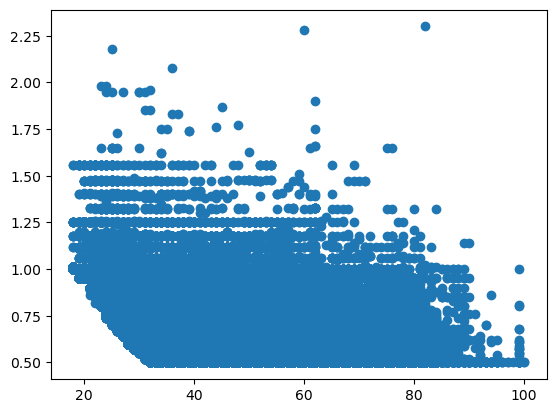

(405763, 12)


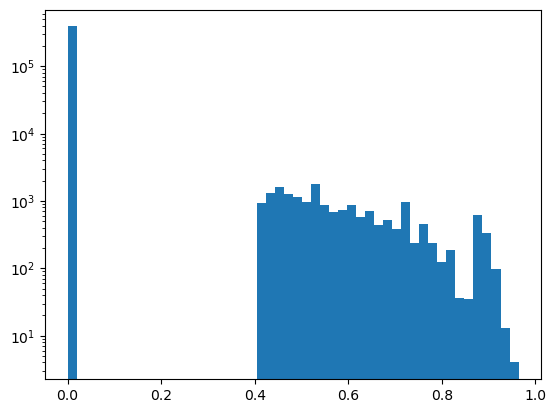

In [2]:
df = pd.read_csv("C:/Users/bogda/Documents/Semester 3/Machine Learning/machine-n-learnings-inc/src/claims_train.csv")
df = filtering(df)

Separating Data into numerical and categorical

In [3]:
df_clean = df.drop(columns=["ClaimNb", "Exposure","Region"])
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns

Scaling Data for PCA

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[numeric_cols])

Running the PCA on the Data

In [5]:
pca = PCA(n_components=0.9, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (405763, 8)
Reduced shape: (405763, 6)


Plotting the PCA

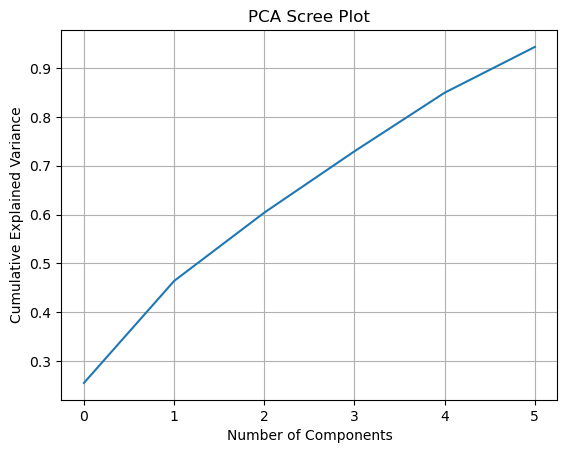

In [6]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.show()

Cleaning the data for Clustering

In [7]:
X_cat = pd.get_dummies(df_clean[categorical_cols], drop_first=True)
X_final = np.hstack([X_pca, X_cat.values])
X_final.shape

(405763, 17)

Clustering

In [8]:
# scores = []
# for k in tqdm(range(2, 10), desc="Evaluating KMeans for different k"):
#     km = KMeans(n_clusters=k, random_state=42,)
#     labels = km.fit_predict(X_final)
#     score = silhouette_score(X_final, labels)
#     scores.append((k, score))

# best_k = max(scores, key=lambda x: x[1])[0]
# print("Best k by silhouette score:", best_k)
print("Best k by silhouette score:", 3)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_final)

df["Cluster"] = clusters

Best k by silhouette score: 3


Plotting Clustering

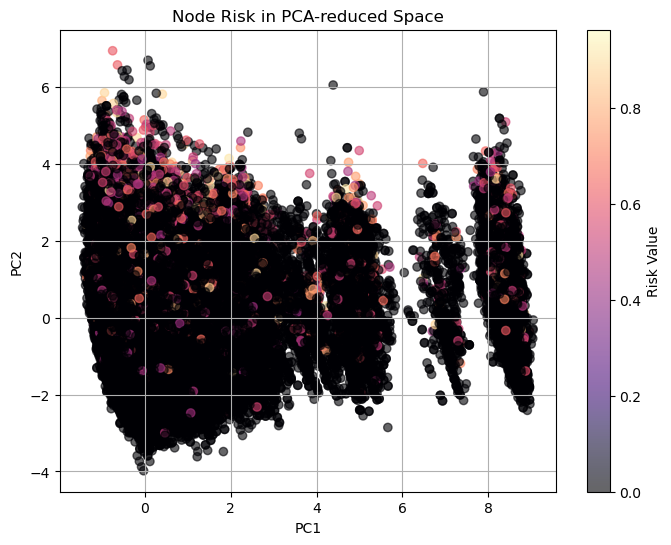

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Risk"], cmap="magma", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Node Risk in PCA-reduced Space")
plt.colorbar(label="Risk Value")
plt.grid(True)
plt.show()

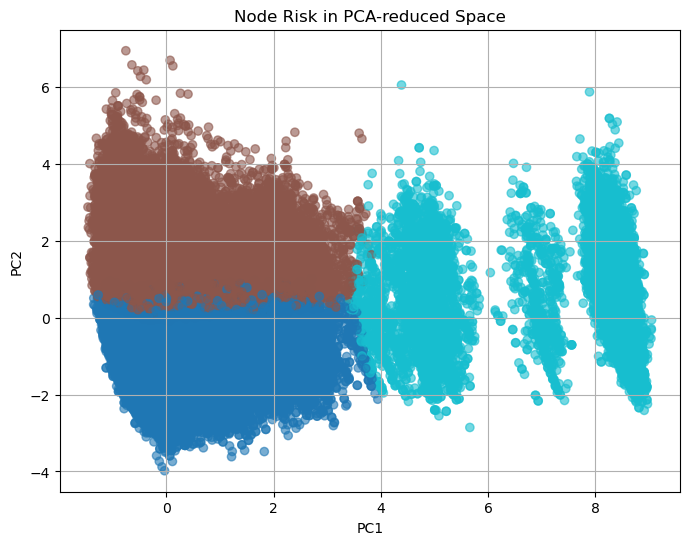

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="tab10", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Node Risk in PCA-reduced Space")
plt.grid(True)
plt.show()

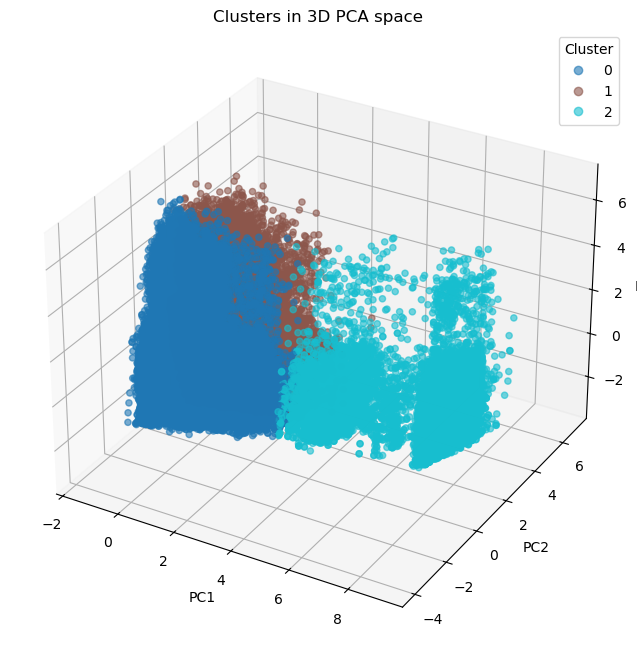

In [10]:
# 3D scatterplot using first three principal components
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter( X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=clusters, cmap="tab10", alpha=0.6)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Clusters in 3D PCA space")

plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

Printing counts of Clusters

In [11]:
print(df["Cluster"].value_counts())

Cluster
0    254815
1    140209
2     10739
Name: count, dtype: int64
